In [1]:
import anndata as ad
import numpy as np
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
import h5py

In [2]:
with h5py.File("GSM6578062_human_tonsil_HVG.h5", "r") as f:
    print(f.keys())
    cell = [i.decode("utf-8") for i in f["cell"][:]]
    gene = [i.decode("utf-8") for i in f["gene"][:]]
    prot = [i.decode("utf-8") for i in f["protein"][:]]
    pos = f["pos"][:]

<KeysViewHDF5 ['X_gene', 'X_protein', 'cell', 'gene', 'pos', 'protein']>


In [3]:
X_gene = sc.read_hdf("GSM6578062_human_tonsil_HVG.h5", key="X_gene")
X_protein = sc.read_hdf("GSM6578062_human_tonsil_HVG.h5", key="X_protein")

In [7]:
adata_rna = ad.AnnData(X=X_gene.X)
adata_rna.obs_names = cell
adata_rna.var_names = gene
adata_rna.obsm["pos"] = pos

In [8]:
adata_prot = ad.AnnData(X=X_protein.X)
adata_prot.obs_names = cell
adata_prot.var_names = prot
adata_prot.obsm["pos"] = pos

In [9]:
mdata = md.MuData({"RNA": adata_rna, "Protein": adata_prot})
mdata

MuData object with n_obs × n_vars = 2492 × 2283
  2 modalities
    RNA:	2492 x 2000
      obsm:	'pos'
    Protein:	2492 x 283
      obsm:	'pos'

/ubc/cs/research/beaver/projects/carlos/conda_envs/pgm/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/ubc/cs/research/beaver/projects/carlos/conda_envs/pgm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3141167/1116083432.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mdata.mod["RNA"])


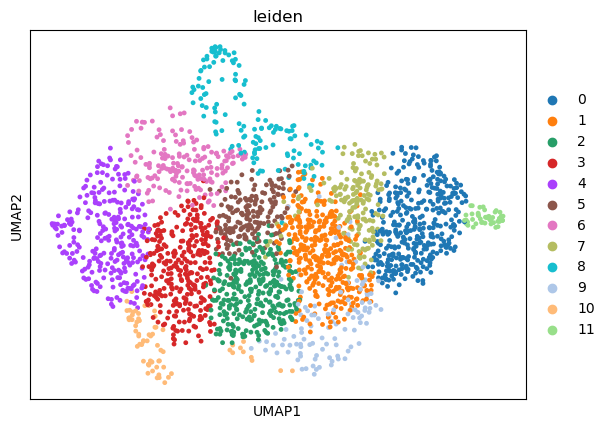

In [10]:
sc.pp.neighbors(mdata.mod["RNA"])
sc.tl.leiden(mdata.mod["RNA"])

sc.tl.umap(mdata.mod["RNA"])
sc.pl.umap(mdata.mod["RNA"], color="leiden")

/ubc/cs/research/beaver/projects/carlos/conda_envs/pgm/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 283 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


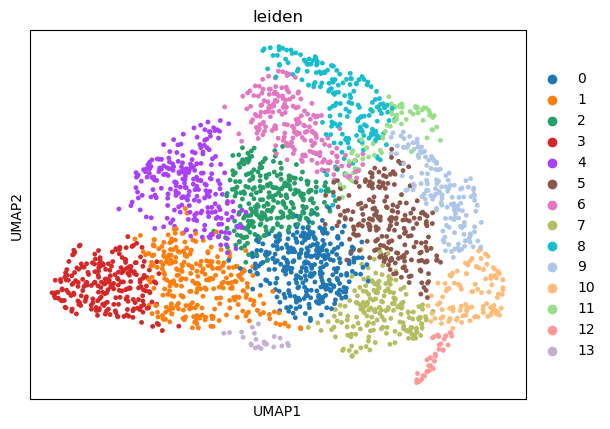

In [11]:
sc.pp.neighbors(mdata.mod["Protein"])
sc.tl.leiden(mdata.mod["Protein"])

sc.tl.umap(mdata.mod["Protein"])
sc.pl.umap(mdata.mod["Protein"], color="leiden")

In [16]:
mdata["RNA"].obsm["pos"]

array([[29., 42.],
       [44., 36.],
       [34.,  6.],
       ...,
       [23., 48.],
       [ 8., 44.],
       [ 5., 44.]])

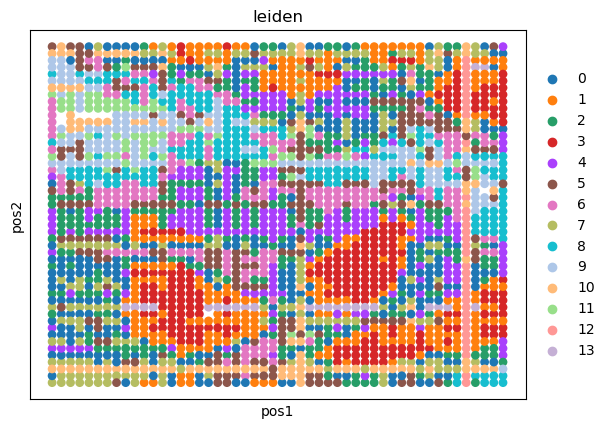

In [13]:
sc.pl.embedding(mdata["Protein"], basis="pos", color="leiden", s=160, show=False)
plt.gca().invert_yaxis()

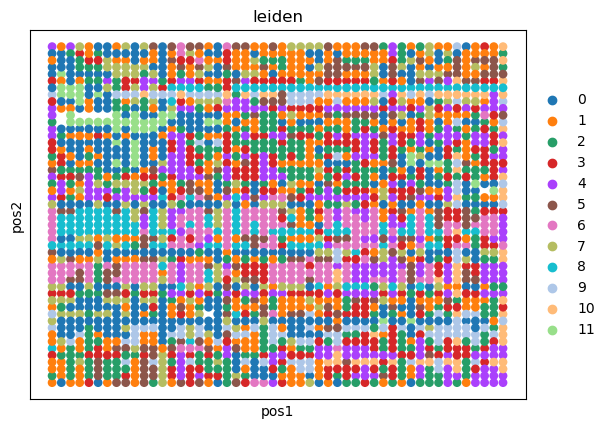

In [14]:
sc.pl.embedding(mdata["RNA"], basis="pos", color="leiden", s=160, show=False)
plt.gca().invert_yaxis()